# A Flux-Based Estimate of the Interstellar Object Contribution to the Galactic Baryon Budget

This notebook estimates how much of the Milky Way’s mass could, in principle,  
be carried by **interstellar objects (ISOs)** – small bodies on unbound  
trajectories such as 1I/ʻOumuamua, 2I/Borisov, and 3I/ATLAS.

The logic proceeds in a strictly defined chain:

---

## 1. From detections to local ISO number density

We treat ISO detections as a flux through a spherical observational  
cross-section of radius $R_{\mathrm{det}}$ and relative speed $v$.  
If $N$ objects are detected over a time baseline $T$, the observed rate is

$$
\lambda_{\mathrm{obs}} = \frac{N}{T} \quad [\mathrm{s}^{-1}] \, .
$$

For a homogeneous and isotropic ISO sea, the **observed number density** is

$$
n_{\mathrm{ISO}} =
  \frac{\lambda_{\mathrm{obs}}}{\pi R_{\mathrm{det}}^2\, v}
  \quad [\mathrm{m}^{-3}] \, .
$$

We adopt an effective detection radius given by the mean of the individual  
detection radii in astronomical units (AU).

---

## 2. From number density to local ISO mass density (LIMD)

Given an average ISO mass $m_{\mathrm{avg}}$, the **Local ISO Mass  
Density (LIMD)** at the Solar position is

$$
\rho_{\mathrm{LIMD}} = m_{\mathrm{avg}} \, n_{\mathrm{ISO}}
\quad [\mathrm{kg\,m^{-3}}] \, .
$$

To model incomplete detection, we introduce a **detection completeness**  
parameter $C_{\rm det} \in (0,1]$. This represents the fraction of ISO  
crossings through the survey region that lead to discovery. The **true**  
local number density is then

$$
n_{\mathrm{ISO,true}}(C_{\rm det})
  = \frac{n_{\mathrm{ISO}}}{C_{\rm det}} \, ,
$$

and the corresponding **true** mass density is

$$
\rho_{\mathrm{LIMD,true}}(C_{\rm det})
  = \frac{\rho_{\mathrm{LIMD}}}{C_{\rm det}} \, .
$$

A completeness much smaller than $C_{\rm det} \sim 0.01$ would imply local ISO  
number densities that exceed all pre-ʻOumuamua upper limits by orders of  
magnitude, so such extreme values are not astrophysically plausible.

---

## 3. Spatial extrapolation using Galactic density templates

We assume that the large-scale ISO mass density follows a chosen Galactic  
mass component:

- **Stellar** density field,  
- **Baryonic** density (stars + bulge + gas),  
- **Total** mass density (baryons + dark halo),  
- A **Uniform** distribution for comparison.

Let $\rho_T(R,z)$ be the chosen template density in cylindrical  
coordinates $(R,z)$ and $\rho_T(R_\odot,0)$ its value at the Solar  
position. We construct the ISO density field as a purely **scaled** version:

$$
\rho_{\mathrm{ISO}}(R,z; C_{\rm det}, m_{\mathrm{avg}})
  = \rho_{\mathrm{LIMD,true}}(C_{\rm det})\,
    \frac{\rho_T(R,z)}{\rho_T(R_\odot,0)} \, .
$$

This means that the Solar neighbourhood density is fixed to  
$\rho_{\mathrm{LIMD,true}}(C_{\rm det})$, and the spatial variation is taken  
from the McMillan (2017) mass models as implemented in the  
`galpy.potential.McMillan17` class.

---

## 4. Total ISO mass by Galactic integration

We integrate the ISO density over a cylindrical volume:

- Radius range: $0.1 \le R \le 20\,\mathrm{kpc}$,  
- Height range: $-3 \le z \le +3\,\mathrm{kpc}$.

In cylindrical coordinates, the volume element is

$$
dV = 2\pi R\, dR\, dz \, ,
$$

and the total ISO mass is

$$
M_{\mathrm{ISO}}(C_{\rm det}, m_{\mathrm{avg}})
  = \int \rho_{\mathrm{ISO}}(R,z; C_{\rm det}, m_{\mathrm{avg}})\,
         2\pi R\, dR\, dz \, .
$$

In practice, we evaluate this integral numerically on a regular grid  
in $(R,z)$ using the McMillan (2017) density functions.

---

## 5. Baryon fraction as a function of detection completeness

We adopt literature values for the Milky Way's:

- Known baryonic mass $M_{\mathrm{bary,known}}$ (stars + gas + dust),  
- Total mass $M_{\mathrm{total}}$.

The baryon fraction implied by a given ISO mass is then

$$
f_b(C_{\rm det}, m_{\mathrm{avg}})
  = \frac{M_{\mathrm{bary,known}} + M_{\mathrm{ISO}}(C_{\rm det}, m_{\mathrm{avg}})}
         {M_{\mathrm{total}}} \, .
$$

We compare this to:

- The Milky Way's **known** baryon fraction without ISOs:

  $$
  f_{b,\mathrm{MW,known}}
    = \frac{M_{\mathrm{bary,known}}}{M_{\mathrm{total}}}
    \approx 0.056 \, ,
  $$

- A representative baryon fraction for Milky-Way–mass halos from  
  external-galaxy studies, $f_{b,\mathrm{expected}} \approx 0.08$,

- The cosmic baryon fraction $f_{b,\mathrm{cosmic}} \approx 0.158$,

- The unphysical limit $f_b = 1$ where all mass is baryonic.

---

## 6. Uncertainties: Poisson rate and ISO mass distribution

Because only three ISOs are known, we explicitly propagate:

- **Poisson uncertainty** in the event rate $\lambda$ using the  
  Garwood (exact) 95% confidence interval,

- **Non-parametric bootstrap uncertainty** in the average ISO mass  
  $m_{\mathrm{avg}}$, based on resampling the three measured masses  
  with replacement.

For each spatial template, we combine these uncertainties into:

- A **mass-only band** (fixing $\lambda$),  
- A **rate-only band** (fixing $m_{\mathrm{avg}}$),  
- A **combined band** (extreme combinations of both).

---

## 7. Plots and interpretation

We generate:

- A $2 \times 2$ matrix of panels:
  - three showing full uncertainty bands for ISO densities tracing  
    baryonic, total, and uniform distributions,
  - one summary panel overlaying the best-estimate curves for these  
    three templates.

- A standalone panel showing the **stellar-only** template, which  
  is explicitly identified as a **ruled-out** model because it  
  quickly leads to implausibly high baryon fractions.


## 1. Imports, physical constants, and Galactic potential
 
This cell:

- Imports numerical, statistical, and plotting libraries (`numpy`, `scipy.stats`, `matplotlib`),
- Provides access to precise time handling (`datetime`),
- Imports the McMillan (2017) Galactic potential implementation from `galpy`,
- Defines the physical constants required for unit conversions:
  - Astronomical unit ($1\,\mathrm{AU}$ in meters),
  - Solar mass $M_\odot$ in kilograms,
  - Kiloparsec to meter conversion.

The constants are used throughout the notebook for:

- Converting detection radii from AU to meters,
- Converting grid coordinates $(R,z)$ from kiloparsecs to meters,
- Converting integrated masses from kilograms to solar masses.

In [1]:
import numpy as np
from datetime import datetime
from scipy import stats
import matplotlib.pyplot as plt

from galpy.potential import McMillan17

from astropy.constants import au, M_sun
from astropy import units as u

# Physical constants
AU = au.to(u.m).value
Msun = M_sun.to(u.kg).value
kpc_to_m = (1 * u.kpc).to(u.m).value

## 2. Optional pandas support and input error class

This cell:

- Tries to import `pandas` (if available) to allow ISO input as a DataFrame,
- Defines a small custom exception `LIMDInputError` to signal problems
  with how ISO detections are passed into the analysis.
 
We keep this logic minimal and self-contained so that the core LIMD
calculation is not polluted with type checks and error messages.

In [2]:
# Attempt pandas import (optional)
try:
    import pandas as pd
    _HAS_PANDAS = True
except Exception:
    _HAS_PANDAS = False

class LIMDInputError(Exception):
    """Custom exception for malformed LIMD inputs."""
    pass

## 3. Input normalisation: `_extract_records`

ISO detections can be provided either as:

- a **dict-of-dicts**:
  ```python
  {
      "1I/ʻOumuamua": {"mass": ..., "R_detect_AU": ..., "date": datetime(...)},
      "2I/Borisov":   {...},
      ...
  }
  ```
- or as a **pandas DataFrame** with columns
  `["mass", "R_detect_AU", "date"]`.

To avoid cluttering the scientific logic with input plumbing, this helper:

- Converts all supported formats into a **list of uniform dictionaries**,
- Validates that the `date` field is a `datetime` object,
- Raises `LIMDInputError` if the structure is inconsistent.

All downstream calculations treat the result as

$$
\{ m_i, R_{\mathrm{det},i}, t_i \}_{i=1}^N
$$

with no further concern for the original container type.


In [3]:
def _extract_records(data):
    """
    Normalise input into a list of dictionaries:
        [{"mass": kg, "R_detect_AU": AU, "date": datetime}, ...]
    Supported inputs:
      - dict of dicts
      - pandas DataFrame (if available)
    """
    # Case 1: dict-of-dicts
    if isinstance(data, dict):
        records = []
        for name, item in data.items():
            try:
                mass = item["mass"]
                R_au = item["R_detect_AU"]
                date = item["date"]
                velocity = item["v_infty_kms"]
            except KeyError:
                raise LIMDInputError(
                    f"Object '{name}' missing required keys: mass, R_detect_AU, date"
                )
            if not isinstance(date, datetime):
                raise LIMDInputError(
                    f"Object '{name}' has non-datetime 'date' field"
                )
            records.append({"mass": mass, "R_detect_AU": R_au, "date": date, "velocity": velocity*1000})
        return records

    # Case 2: pandas DataFrame
    if _HAS_PANDAS and isinstance(data, pd.DataFrame):
        required = {"mass", "R_detect_AU", "date"}
        if not required.issubset(data.columns):
            raise LIMDInputError(f"DataFrame must contain columns: {required}")

        records = []
        for idx, row in data.iterrows():
            if not isinstance(row["date"], datetime):
                raise LIMDInputError(f"Row {idx} has non-datetime 'date'")
            records.append({
                "mass": row["mass"],
                "R_detect_AU": row["R_detect_AU"],
                "date": row["date"],
            })
        return records

    # If neither of the supported types applies, we fail explicitly
    raise LIMDInputError("Input must be dict-of-dicts or pandas DataFrame.")

## 4. Direct LIMD computation from an explicit rate

This helper function is not used in the main analysis, but it makes  
the algebra explicit and provides a way to explore hypothetical  
detection rates.

Given:

- an explicit Poisson rate $\lambda$ (events per second),  
- an average detection radius $R_{\mathrm{avg}}$ (meters),  
- a characteristic relative velocity $v$ (meters per second),  
- a detection completeness $C_{\rm det}$,  
- an average ISO mass $m_{\mathrm{avg}}$,

the function returns the true local ISO **mass** density:

$$
\rho_{\mathrm{true}} =
  \frac{\lambda}{\pi R_{\mathrm{avg}}^2\, v}\,
  \frac{1}{C_{\rm det}}\,
  m_{\mathrm{avg}} \, .
$$


In [4]:
def compute_LIMD_from_lambda(lam, R_avg_m, velocity, O=1.0, m_avg=1.0):
    """
    Compute LIMD when lambda is given explicitly.

    Parameters
    ----------
    lam : float
        Event rate [1/s].
    R_avg_m : float
        Average detection radius in meters.
    velocity : float
        Relative speed [m/s].
    O : float
        Observability/completeness.
    m_avg : float
        Average mass for the scenario (kg).

    Returns
    -------
    rho_true : float
        True local mass density at the Sun [kg/m^3].
    """
    A = np.pi * R_avg_m**2
    n_observed = lam / (A * velocity)
    n_true     = n_observed / O
    rho_true   = n_true * m_avg
    return rho_true

## 5. Core LIMD computation from the actual ISO sample

This is the main function that converts the observed ISO sample into
local number density and mass density.

Given the extracted records, it:

1. Computes the **time baseline**:
   $$
   T = t_{\max} - t_{\min} \, ,
   $$
   where the dates are the discovery dates of the individual ISOs.

2. Defines the **observed event rate**:
   $$
   \lambda_{\mathrm{obs}} = \frac{N_{\mathrm{detect}}}{T} \, .
   $$

3. Uses the average detection radius
   $$
   R_{\mathrm{avg}} = \langle R_{\mathrm{det},i} \rangle
   $$
   to compute the effective cross-section
   $$
   A = \pi R_{\mathrm{avg}}^2 \, .
   $$

4. Derives the **observed** number density $n_{\mathrm{ISO}}$ via
   $$
   n_{\mathrm{ISO}} =
     \frac{\lambda_{\mathrm{obs}}}{A\, v} \, ,
   $$
   and rescales it by $O$ to obtain
   $n_{\mathrm{ISO,true}} = n_{\mathrm{ISO}} / C_{\rm det}$.

5. Computes the average ISO mass
   $$
   m_{\mathrm{avg}} = \langle m_i \rangle
   $$
   and the corresponding local mass densities
   $$
   \rho_{\mathrm{LIMD}} = m_{\mathrm{avg}}\, n_{\mathrm{ISO}},
   \quad
   \rho_{\mathrm{LIMD,true}} = \rho_{\mathrm{LIMD}} / C_{\rm det} \, .
   $$

The function returns a dictionary containing both the raw and
detection completeness-corrected quantities, plus the baseline, number of detections
and the average detection radius.


In [5]:
def compute_LIMD(data, completeness=1.0):
    """
    Compute local ISO number density and LIMD for a given detection completeness C_det.

    Parameters
    ----------
    data : dict or DataFrame
        Must contain: mass [kg], R_detect_AU [AU], date [datetime], velocity [m/s].
    completeness : float
        Detection completeness O in (0,1].

    Returns
    -------
    dict
        Contains observed and true densities and basic sample diagnostics.
    """
    if completeness <= 0 or completeness > 1:
        raise ValueError("Detection completeness must be within (0,1].")

    records = _extract_records(data)

    masses     = np.array([r["mass"]          for r in records], float)
    radii_AU   = np.array([r["R_detect_AU"]   for r in records], float)
    dates      = [r["date"]                   for r in records]
    velocities = np.array([r["velocity"]      for r in records], float)

    # Time baseline (from first to last detection)
    t_min, t_max = min(dates), max(dates)
    baseline_sec = (t_max - t_min).total_seconds()
    baseline_years = baseline_sec / (365.25 * 24 * 3600)
    if baseline_years <= 0:
        raise LIMDInputError("Detections must span a non-zero interval.")

    # Observed detection rate
    N_detect = len(records)
    lam = N_detect / baseline_sec  # [1/s]

    # Effective detection radius: mean over the sample
    R_avg_AU = radii_AU.mean()
    R_avg_m  = R_avg_AU * AU

    # Effective velocity: mean over the sample
    v_avg = velocities.mean()   # [m/s]

    # Cross-section of observation sphere
    A = np.pi * R_avg_m**2

    # Observed ISO number density (no completeness correction)
    n_ISO = lam / (A * v_avg)  # [m^-3]

    # True number density (corrected by detection completeness)
    n_ISO_true = n_ISO / completeness   # [m^-3]

    # Average mass and mass densities
    m_avg        = masses.mean()
    rho_LIMD     = m_avg * n_ISO             # [kg/m^3]
    rho_LIMD_true = rho_LIMD / completeness

    return {
        "n_ISO": n_ISO,
        "n_ISO_true": n_ISO_true,
        "m_avg": m_avg,
        "rho_LIMD": rho_LIMD,
        "rho_LIMD_true": rho_LIMD_true,
        "baseline_sec": baseline_sec,
        "baseline_years": baseline_years,
        "N_detect": N_detect,
        "R_avg_AU": R_avg_AU,
        "v_avg_mps": v_avg,
        "completeness": completeness,
        "detection_radius_m": R_avg_m/AU,
    }


## 6. Input data: the three known ISOs and baseline LIMD

Here we specify the three detected interstellar objects:

- 1I/ʻOumuamua,
- 2I/Borisov,
- 3I/ATLAS.

For each object we define:

- an approximate mass in kilograms,
- a detection radius in astronomical units,
- the date of discovery (as a `datetime` object).
- velocity at infinity in km/s

We then call `compute_LIMD` with `completeness=1.0` to obtain a
**baseline** local ISO number and mass density corresponding to perfect
detection completeness ($C_{\rm det}=1$). This will later be rescaled for different values
of $C_{\rm det}$.

In [6]:
objects = {
    "1I/ʻOumuamua": {"mass": 1e11,     "R_detect_AU": 0.25, "date": datetime(2017,10,19), "v_infty_kms": 26.33},
    "2I/Borisov":   {"mass": 2.6e11,   "R_detect_AU": 2.98, "date": datetime(2019,8,30), "v_infty_kms": 32.0},
    "3I/ATLAS":     {"mass": 2.6e14,   "R_detect_AU": 3.20, "date": datetime(2025,7,1), "v_infty_kms": 58.0},
}

LIMD_base = compute_LIMD(objects, completeness=1.0)
LIMD_base

{'n_ISO': 9.859198017872121e-37,
 'n_ISO_true': 9.859198017872121e-37,
 'm_avg': 86786666666666.67,
 'rho_LIMD': 8.556469319777285e-23,
 'rho_LIMD_true': 8.556469319777285e-23,
 'baseline_sec': 242956800.0,
 'baseline_years': 7.698836413415469,
 'N_detect': 3,
 'R_avg_AU': 2.143333333333333,
 'v_avg_mps': 38776.666666666664,
 'completeness': 1.0,
 'detection_radius_m': 2.143333333333333}

## 7. Garwood 95 % confidence interval for the Poisson rate

The detection rate $\lambda$ inferred from $N$ events in a time baseline $T$
is subject to Poisson fluctuations.

We construct the **exact** (Garwood) 95 % confidence interval:

$$
\lambda_{\mathrm{low}} =
  \frac{1}{2T}\,
  \chi^2_{2N,\,\alpha/2}, \qquad
\lambda_{\mathrm{high}} =
  \frac{1}{2T}\,
  \chi^2_{2(N+1),\,1-\alpha/2},
$$

with $\alpha = 0.05$. The best estimate is simply
$$
\lambda_{\mathrm{best}} = \frac{N}{T}.
$$

We then define **scaling factors** relative to the best estimate:

$$
s_{\mathrm{low}}  = \frac{\lambda_{\mathrm{low}}}{\lambda_{\mathrm{best}}}, 
\qquad
s_{\mathrm{high}} = \frac{\lambda_{\mathrm{high}}}{\lambda_{\mathrm{best}}}.
$$

These factors are used later to rescale the integrated ISO mass curves
up and down to reflect rate uncertainty only, keeping the ISO mass
distribution fixed.


In [7]:
N = LIMD_base["N_detect"]
T = LIMD_base["baseline_sec"]   # [s]

alpha = 0.05

# Garwood formula:
# λ_low  = 0.5 * χ²[2N,     α/2] / T
# λ_high = 0.5 * χ²[2(N+1), 1-α/2] / T

if N == 0:
    # Special case; not relevant here but included for completeness
    lam_low = 0.0
else:
    lam_low = 0.5 * stats.chi2.ppf(alpha/2, df=2*N) / T

lam_high = 0.5 * stats.chi2.ppf(1 - alpha/2, df=2*(N + 1)) / T
lam_best = N / T

scale_low  = lam_low  / lam_best
scale_high = lam_high / lam_best

print("Garwood 95% λ interval:")
print(f"λ_low  = {lam_low:.4e}   ({scale_low:.3f} × λ_best)")
print(f"λ_best = {lam_best:.4e}")
print(f"λ_high = {lam_high:.4e}   ({scale_high:.3f} × λ_best)")

Garwood 95% λ interval:
λ_low  = 2.5464e-09   (0.206 × λ_best)
λ_best = 1.2348e-08
λ_high = 3.6086e-08   (2.922 × λ_best)


## 8. Galactic density templates from McMillan (2017)

In this section we:

1. Build a regular grid in cylindrical coordinates $(R,z)$:
   - $R$ from $0.1$ to $20\,\mathrm{kpc}$,
   - $z$ from $-3$ to $+3\,\mathrm{kpc}$.

2. Evaluate the McMillan (2017) Milky Way model components:
   - Stellar density,
   - Bulge density,
   - Gas density,
   - Dark halo density.

3. Construct:
   - **Stellar-only** density $\rho_{\star}(R,z)$,
   - **Baryonic** density
     $$
     \rho_{\mathrm{bary}}(R,z)
       = \rho_{\star}(R,z) + \rho_{\mathrm{bulge}}(R,z) +
         \rho_{\mathrm{gas}}(R,z),
     $$
   - **Total** mass density
     $$
     \rho_{\mathrm{total}}(R,z)
       = \rho_{\mathrm{bary}}(R,z) + \rho_{\mathrm{halo}}(R,z),
     $$
   - A **uniform** density field for comparison.

4. Compute the template values at the Solar position
   $(R_\odot, z=0)$, where we take $R_\odot = 8.2\,\mathrm{kpc}$.

We then store all templates in a dictionary `templates` that is used
in the subsequent integration step.


In [8]:
# Radial and vertical grids (in kpc)
R = np.linspace(0.1, 20, 400)   # kpc
z = np.linspace(-3, 3, 120)     # kpc

RR, ZZ = np.meshgrid(R, z, indexing='ij')  # shape (nR, nz)

# Vectorized densities from McMillan17
stellar = np.vectorize(McMillan17.stellar_dens)
bulge   = np.vectorize(McMillan17.bulge_dens)
gas     = np.vectorize(McMillan17.gas_dens)
halo    = np.vectorize(lambda R, z: McMillan17.McMillan_halo.dens(R, z))

rho_stellar_grid = stellar(RR, ZZ)
rho_bulge_grid   = bulge(RR, ZZ)
rho_gas_grid     = gas(RR, ZZ)
rho_halo_grid    = halo(RR, ZZ)

# Baryonic and total mass templates
rho_bary_grid    = rho_stellar_grid + rho_bulge_grid + rho_gas_grid
rho_total_grid   = rho_bary_grid + rho_halo_grid

# Uniform template (for comparison)
rho_uniform_grid = np.ones_like(RR)

# Normalizations at the Sun (R_sun = 8.2 kpc, z = 0)
R_sun = 8.2
rho_stellar_sun = stellar(R_sun, 0.0)
rho_bary_sun    = (stellar(R_sun,0.0)
                   + bulge(R_sun,0.0)
                   + gas(R_sun,0.0))
rho_total_sun   = (rho_bary_sun
                   + halo(R_sun,0.0))
rho_uniform_sun = 1.0  # by construction

templates = {
    "stellar":  (rho_stellar_grid, rho_stellar_sun),
    "baryonic": (rho_bary_grid,    rho_bary_sun),
    "total":    (rho_total_grid,   rho_total_sun),
    "uniform":  (rho_uniform_grid, rho_uniform_sun),
}

## 9. Integration of ISO mass over a given template

This function implements the Galactic integration step:

- We are given a **local true ISO mass density** at the Sun,
  $\rho_{\mathrm{true,local}}$ (this encodes the LIMD and the
  detection completeness $C_{\rm det}$),
- and a chosen template
  $\rho_T(R,z)$ with Solar value $\rho_T(R_\odot,0)$.

We define the ISO density field as:
$$
\rho_{\mathrm{ISO}}(R,z)
  = \rho_{\mathrm{true,local}}\,
    \frac{\rho_T(R,z)}{\rho_T(R_\odot,0)}.
$$

We then:

1. Convert $R$ and $z$ from kiloparsecs to meters,
2. Compute the cylindrical volume element
   $$
   dV = 2\pi R\, dR\, dz,
   $$
3. Sum up $\rho_{\mathrm{ISO}}(R,z)\, dV$ over the grid to obtain the total
   ISO mass in kilograms:
   $$
   M_{\mathrm{ISO}} =
     \sum_{R,z}
       \rho_{\mathrm{ISO}}(R,z)\,
       2\pi R\, \Delta R\, \Delta z \, .
   $$

In [9]:
def integrate_IS_mass(rho_true_local, rho_template_grid, rho_template_sun):
    """
    Compute total ISO mass for a given local true LIMD at (R_sun, 0),
    assuming ISO density follows the provided template.

    Parameters
    ----------
    rho_true_local : float
        Local true ISO mass density at (R_sun, 0) [kg/m^3].
    rho_template_grid : ndarray
        Template density values on the (R,z) grid.
    rho_template_sun : float
        Template density value at the Sun.

    Returns
    -------
    float
        Total ISO mass in the integration volume [kg].
    """
    # ISO mass density at all (R,z) via scaling to local value
    rho_IS = rho_true_local * (rho_template_grid / rho_template_sun)  # [kg/m^3]

    # Convert R, z grid into meters
    R_m = RR * kpc_to_m
    z_m = ZZ * kpc_to_m

    # Grid spacings in meters
    dR = np.gradient(R) * kpc_to_m
    dz = np.gradient(z) * kpc_to_m

    # Turn 1D spacings into broadcastable 2D arrays
    dR_2d = dR[:, None]
    dz_2d = dz[None, :]

    # Cylindrical volume element: dV = 2*pi*R * dR * dz
    dV = 2.0 * np.pi * R_m * dR_2d * dz_2d

    # Total mass in kg
    M_total_IS = np.sum(rho_IS * dV)
    return M_total_IS

## 10. External Milky Way mass anchors

We do **not** derive the Milky Way's baryonic or total mass from our grid.
Instead, we adopt literature values (rounded for clarity):

- Stellar mass:
  $$
  M_\star \approx 5.4 \times 10^{10}\,M_\odot \, ,
  $$
- Gas mass:
  $$
  M_{\mathrm{gas}} \approx 1.2 \times 10^{10}\,M_\odot \, ,
  $$
- Dust mass (assumed):
  $$
  M_{\mathrm{dust}} = 0.01\,M_{\mathrm{gas}} \, .
  $$

The total known baryonic mass is then
$$
M_{\mathrm{bary,known}}
  = M_\star + M_{\mathrm{gas}} + M_{\mathrm{dust}}
  \approx 6.6 \times 10^{10}\,M_\odot \, .
$$

For the total Milky Way mass we adopt:
$$
M_{\mathrm{total}} = 1.17 \times 10^{12}\,M_\odot \, .
$$

Finally, we adopt a representative **expected** baryon fraction for
Milky-Way–mass halos:
$$
f_{b,\mathrm{expected}} \approx 0.08 \, .
$$

These anchors are used to compute and interpret the implied baryon fraction
$f_b(O)$ from the ISO contribution.

In [10]:
# Known baryonic mass components (Quantities)
M_star = 5.4e10 * u.Msun
M_gas  = 1.2e10 * u.Msun
M_dust = 0.01 * M_gas

M_bary_known_q = M_star + M_gas + M_dust     # Quantity in Msun
M_bary_known   = M_bary_known_q.value        # float

# Total Milky Way mass
M_total_q = 1.17e12 * u.Msun
M_total   = M_total_q.value

# Expected baryon fraction from external galaxies
f_b_expected = 0.08

print("Assumed MW mass anchors:")
print(f"Baryonic: {M_bary_known:.1e} Msun")
print(f"Total:    {M_total:.1e} Msun")
print(f"f_b expected: {f_b_expected:.2}")

Assumed MW mass anchors:
Baryonic: 6.6e+10 Msun
Total:    1.2e+12 Msun
f_b expected: 0.08


## 11. Bootstrap uncertainty on the average ISO mass

The ISO mass distribution is essentially unconstrained with only
three objects:

- 1I/ʻOumuamua,
- 2I/Borisov,
- 3I/ATLAS.

Rather than imposing a parametric mass function, we use a
**non-parametric bootstrap**:

1. Collect the three measured masses $\{m_i\}$,
2. Generate many bootstrap samples of size 3 **with replacement**,
3. For each sample, compute the sample mean $\bar{m}$,
4. Use the 2.5th and 97.5th percentiles of this bootstrap distribution
   as an empirical 95 % interval for a "representative" average mass.

This is not a rigorous interval for a formal underlying distribution,
but it faithfully reflects how sensitive our conclusions are to the
fact that our sample consists of one very massive object (3I/ATLAS)
and two much lighter ones.

We record:

- `m_avg_best`: the straight mean of the three actual masses,
- `m_avg_low`, `m_avg_high`: the 95 % bootstrap interval.

In [11]:
# Observed ISO masses (kg)
masses = np.array([objects[name]["mass"] for name in objects])

# Best estimate of average mass
m_avg_best = masses.mean()

# Bootstrap
rng = np.random.default_rng(42)
n_boot = 200000

boot_means = []
for _ in range(n_boot):
    sample = rng.choice(masses, size=3, replace=True)
    boot_means.append(sample.mean())

boot_means = np.array(boot_means)

m_avg_low, m_avg_high = np.percentile(boot_means, [2.5, 97.5])

print("Bootstrap average ISO mass:")
print(f"  Best estimate: {m_avg_best:.3e} kg")
print(f"  95% CI low  : {m_avg_low:.3e} kg")
print(f"  95% CI high : {m_avg_high:.3e} kg")

Bootstrap average ISO mass:
  Best estimate: 8.679e+13 kg
  95% CI low  : 1.000e+11 kg
  95% CI high : 2.600e+14 kg


## 12. Baryon fraction as a function of detection completeness

The central diagnostic we care about is the baryon fraction
$$
f_b(C_{\rm det}) =
  \frac{M_{\mathrm{bary,known}} + M_{\mathrm{ISO}}(C_{\rm det})}
       {M_{\mathrm{total}}} \, ,
$$
where:

- $M_{\mathrm{bary,known}}$ is fixed,
- $M_{\mathrm{ISO}}(C_{\rm det})$ is the ISO mass implied by a given detection completeness $C_{\rm det}$,
- $M_{\mathrm{total}}$ is the externally anchored Milky Way mass.

In this cell we:

1. Define a logarithmically spaced **detection completeness axis**
   $$
   C_{\rm det} \in [0.01, 1.0] \, ,
   $$
   where $C_{\rm det}=1$ corresponds to perfect completeness and smaller values
   imply more missed ISOs.

2. For each template:

   - Compute the true local ISO mass density at the Sun for:
     - the best average mass $m_{\mathrm{avg,best}}$,
     - the low bootstrap mass $m_{\mathrm{avg,low}}$,
     - the high bootstrap mass $m_{\mathrm{avg,high}}$,
     at each detection completeness $C_{\rm det}$:
     $$
     \rho_{\mathrm{true}}(C_{\rm det}) =
       \frac{n_{\mathrm{ISO}} m_{\mathrm{avg}}}{C_{\rm det}}.
     $$

   - Integrate this density over the Galactic cylinder to obtain:
     $$
     M_{\mathrm{ISO,best}}(C_{\rm det}),\,
     M_{\mathrm{ISO,low}}(C_{\rm det}),\,
     M_{\mathrm{ISO,high}}(C_{\rm det}) \, .
     $$

   - Convert to solar masses and compute the corresponding
     baryon fractions:
     $$
     f_{b,\mathrm{best}}(C_{\rm det})
       = \frac{M_{\mathrm{bary,known}} + M_{\mathrm{ISO,best}}(C_{\rm det})}
              {M_{\mathrm{total}}}
     $$
     and analogously for the low and high mass cases.

3. Store all of this in a `results` dictionary keyed by template name.

**Note** that in this step, only the **mass distribution uncertainty** is
included. We add the **rate uncertainty** (from the Garwood interval)
in the next cell.

In [12]:
# Fixed observed ISO number density (O=1)
n_ISO_obs = LIMD_base["n_ISO"]  # [m^-3]

# completeness values: 1.0 → 0.01
completeness_axis = np.logspace(0, -2, 60)

results = {}  # will store outputs for each spatial template

for model_name, (rho_template_grid, rho_template_sun) in templates.items():
    
    f_b_best_list = []
    f_b_low_list  = []
    f_b_high_list = []

    M_IS_best_list = []
    M_IS_low_list  = []
    M_IS_high_list = []

    for Cdet in completeness_axis:
        # True mass densities at the Sun (for different average masses)
        rho_true_best = (n_ISO_obs * m_avg_best) / Cdet
        rho_true_low  = (n_ISO_obs * m_avg_low)  / Cdet
        rho_true_high = (n_ISO_obs * m_avg_high) / Cdet

        # Integrate mass across Galaxy for this template
        M_best_kg = integrate_IS_mass(rho_true_best,
                                      rho_template_grid,
                                      rho_template_sun)
        M_low_kg  = integrate_IS_mass(rho_true_low,
                                      rho_template_grid,
                                      rho_template_sun)
        M_high_kg = integrate_IS_mass(rho_true_high,
                                      rho_template_grid,
                                      rho_template_sun)

        # Convert to solar masses
        M_best = M_best_kg / Msun
        M_low  = M_low_kg  / Msun
        M_high = M_high_kg / Msun

        M_IS_best_list.append(M_best)
        M_IS_low_list.append(M_low)
        M_IS_high_list.append(M_high)

        # Baryon fractions for each mass scenario
        f_b_best_list.append((M_bary_known + M_best) / M_total)
        f_b_low_list.append ((M_bary_known + M_low)  / M_total)
        f_b_high_list.append((M_bary_known + M_high) / M_total)

    # Store results in dict
    results[model_name] = {
        "f_b_best":  np.array(f_b_best_list),
        "f_b_low":   np.array(f_b_low_list),
        "f_b_high":  np.array(f_b_high_list),
        "M_best":    np.array(M_IS_best_list),
        "M_low":     np.array(M_IS_low_list),
        "M_high":    np.array(M_IS_high_list),
    }

print("Finished computing mass-uncertainty curves for all templates.")


Finished computing mass-uncertainty curves for all templates.


## 13. Adding Poisson rate (λ) uncertainty and combined confidence bands

So far, the `results` dictionary captures only the uncertainty due
to the poorly constrained ISO mass distribution (via the bootstrap).

In this cell we fold in the **Poisson rate uncertainty** from the
Garwood interval:

- For a given template, the array `M_best(C_{\rm det})` represents the ISO mass
  when both:
  - the rate is fixed to $\lambda_{\mathrm{best}}$,
  - the average mass is fixed to $m_{\mathrm{avg,best}}$.

- Rate-only confidence interval:
  $$
  M_{\lambda,\mathrm{low}}(C_{\rm det})
    = s_{\mathrm{low}}\, M_{\mathrm{best}}(C_{\rm det}),
  \quad
  M_{\lambda,\mathrm{high}}(C_{\rm det})
    = s_{\mathrm{high}}\, M_{\mathrm{best}}(C_{\rm det}),
  $$
  where $s_{\mathrm{low}}$ and $s_{\mathrm{high}}$ are the scaling
  factors derived from the Garwood interval.

- Combined (rate × mass) extremes:
  $$
  M_{\mathrm{comb,low}}(C_{\rm det})
    = s_{\mathrm{low}}\, M_{\mathrm{low}}(C_{\rm det}),
  \quad
  M_{\mathrm{comb,high}}(C_{\rm det})
    = s_{\mathrm{high}}\, M_{\mathrm{high}}(C_{\rm det}),
  $$
  i.e. we combine the lowest plausible mass with the lowest plausible
  rate, and the highest plausible mass with the highest plausible rate.

These masses are then converted back into baryon fractions and stored as:

- `f_b_lambda_low`, `f_b_lambda_high`  (rate-only CI),
- `f_b_comb_low`, `f_b_comb_high`      (combined CI).

In [13]:
# ================================================================
#  Construct λ-CI (mass fixed), mass-CI (λ fixed), combined CI
# ================================================================

for template_name, res in results.items():

    M_best = res["M_best"]   # ISO mass array [Msun]
    M_low  = res["M_low"]
    M_high = res["M_high"]

    # --- λ-only CI (mass fixed at best)
    M_lambda_low  = M_best * scale_low
    M_lambda_high = M_best * scale_high

    res["f_b_lambda_low"]  = (M_bary_known + M_lambda_low)  / M_total
    res["f_b_lambda_high"] = (M_bary_known + M_lambda_high) / M_total

    # --- Combined (λ × mass extremes)
    M_combined_low  = M_low  * scale_low
    M_combined_high = M_high * scale_high

    res["f_b_comb_low"]  = (M_bary_known + M_combined_low)  / M_total
    res["f_b_comb_high"] = (M_bary_known + M_combined_high) / M_total

print("Added λ-CI and combined CI to results{} structure.")

Added λ-CI and combined CI to results{} structure.


## 14. Baryon fraction vs observabilityt

These are main diagnostic figures.

- ISO density tracing the **baryonic** template,
- ISO density tracing the **total** (baryons + halo) template,
- ISO density tracing a **uniform** distribution,
- Summary figure  with only the **best-estimate** curves
  for all three templates overplotted.

For each of the three detailed figures we show:

- A **purple shaded band** for the combined mass × rate uncertainty
  (`f_b_comb_low`–`f_b_comb_high`),
- A **blue shaded band** for the mass-only uncertainty
  (`f_b_low`–`f_b_high`, rate fixed),
- An **orange shaded band** for the rate-only uncertainty
  (`f_b_lambda_low`–`f_b_lambda_high`, mass fixed),
- A **solid blue line** for the best-estimate baryon fraction
  `f_b_best`.

We also show horizontal reference lines:

- Dotted grey line at $f_{b,\mathrm{MW,known}} \approx 0.056$,
- Dashed green line at $f_{b,\mathrm{expected}} \approx 0.08$,
- Dash-dotted red line at the cosmic baryon fraction $f_{b,\mathrm{cosmic}}\approx 0.158$,
- Dotted black line at $f_b = 1$ (unphysical, all mass baryonic).

Both axes are logarithmic:

- $x$-axis: detection completeness $C_{\rm det}$ from 1 to 0.01 (log scale),
- $y$-axis: baryon fraction $f_b$ (log scale).

The summary panel overlays the best-estimate $f_b(C_{\rm det})$ curves for the
three main spatial templates (baryonic, total, uniform) and repeats
the same reference lines. This panel is useful to quickly see
how different spatial assumptions change the tension with known and
expected baryon fractions.

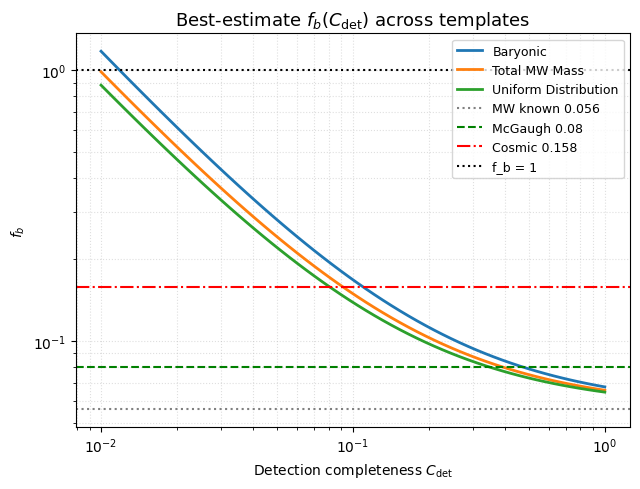

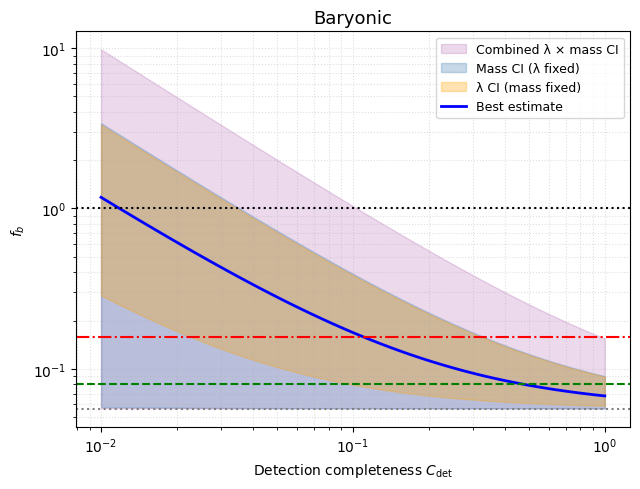

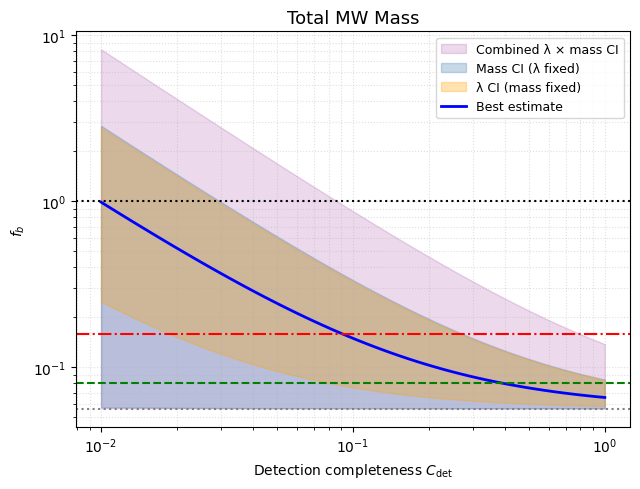

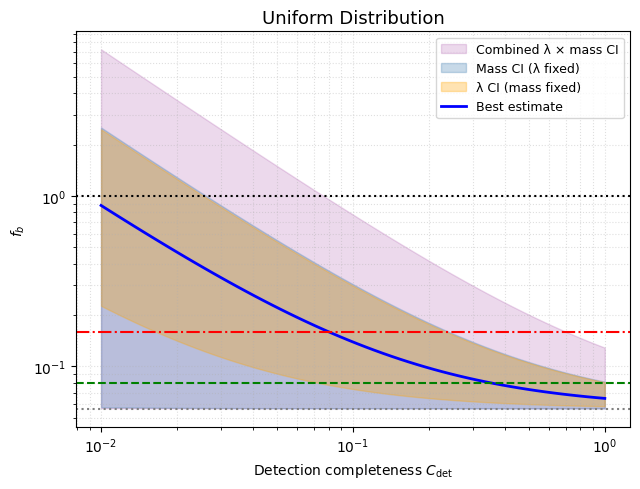

In [20]:

template_order = ["baryonic", "total", "uniform"]
titles = {
    "baryonic": "Baryonic",
    "total":    "Total MW Mass",
    "uniform":  "Uniform Distribution",
}

# ================================================================
#  FIGURE 1: summary panel only (three best-estimate curves)
# ================================================================
plt.figure(figsize=(6.5, 5))

for template in template_order:
    res = results[template]
    fb_best = res["f_b_best"]
    plt.plot(
        completeness_axis, fb_best,
        lw=2, label=titles[template]
    )

plt.axhline(0.056, ls=":",  color="gray",  label="MW known 0.056")
plt.axhline(0.08,  ls="--", color="green", label="McGaugh 0.08")
plt.axhline(0.158, ls="-.", color="red",   label="Cosmic 0.158")
plt.axhline(1.0,   ls=":",  color="black", label="f_b = 1")

plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", ls=":", alpha=0.4)
plt.title("Best-estimate $f_b(C_{\\rm det})$ across templates", fontsize=13)
plt.ylabel(r"$f_b$")
plt.xlabel("Detection completeness $C_{\\rm det}$")
plt.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("figure1.pdf", dpi=600)   # High quality PDF for JCAP
plt.show()


# ================================================================
#  FIGURES 2–4: one per template, full uncertainty bands
# ================================================================
for fig_idx, template in enumerate(template_order, start=2):
    res = results[template]

    fb_best      = res["f_b_best"]
    fb_mass_low  = res["f_b_low"]
    fb_mass_high = res["f_b_high"]
    fb_lam_low   = res["f_b_lambda_low"]
    fb_lam_high  = res["f_b_lambda_high"]
    fb_comb_low  = res["f_b_comb_low"]
    fb_comb_high = res["f_b_comb_high"]

    plt.figure(figsize=(6.5, 5))

    # Combined λ × mass CI
    plt.fill_between(
        completeness_axis, fb_comb_low, fb_comb_high,
        color="purple", alpha=0.15,
        label="Combined λ × mass CI"
    )

    # Mass CI
    plt.fill_between(
        completeness_axis, fb_mass_low, fb_mass_high,
        color="steelblue", alpha=0.30,
        label="Mass CI (λ fixed)"
    )

    # λ CI
    plt.fill_between(
        completeness_axis, fb_lam_low, fb_lam_high,
        color="orange", alpha=0.30,
        label="λ CI (mass fixed)"
    )

    # Best estimate
    plt.plot(
        completeness_axis, fb_best,
        color="blue", lw=2,
        label="Best estimate"
    )

    # Reference lines
    plt.axhline(0.056, ls=":",  color="gray")
    plt.axhline(0.08,  ls="--", color="green")
    plt.axhline(0.158, ls="-.", color="red")
    plt.axhline(1.0,   ls=":",  color="black")

    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, which="both", ls=":", alpha=0.4)
    plt.title(titles[template], fontsize=13)
    plt.ylabel(r"$f_b$")
    plt.xlabel("Detection completeness $C_{\\rm det}$")
    plt.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.savefig(f"figure{fig_idx}.pdf", dpi=600)   # JCAP-quality PDF
    plt.show()

## 15. Stellar-only ISO template: ruled-out model

Finally, we show the case where ISOs are assumed to trace the **stellar**
density only (no gas, no halo). This panel is intentionally separated,
because:

- It tends to push the ISO mass into regions dominated by stars
  (e.g. the inner Galaxy),
- For plausible values of the detection completeness $C_{\rm det}$ and bootstrap mass range,
  the implied baryon fraction $f_b$ quickly becomes **implausibly large**,
  often exceeding even the cosmic baryon fraction.

In other words, if ISOs truly followed the stellar density alone, the
densities implied by the local detections would already be uncomfortably
large compared to standard expectations. This motivates our choice to
focus on the **baryonic**, **total**, and **uniform** templates in the main
analysis and to explicitly label the stellar-tracing ISO model as
**"ruled out"** in the caption.

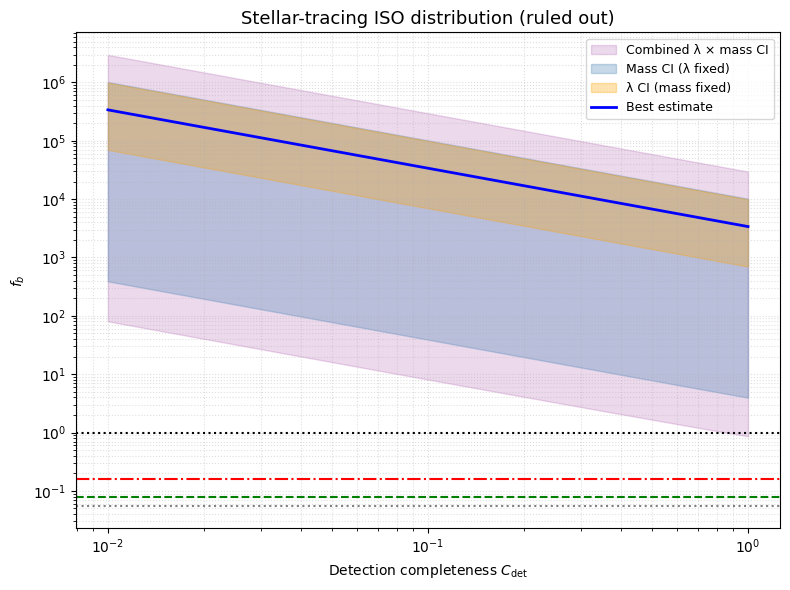

In [15]:
# ================================================================
#  Figure 5: Stellar-only template plot (rejected model)
# ================================================================

template = "stellar"
res = results[template]

fb_best      = res["f_b_best"]
fb_mass_low  = res["f_b_low"]
fb_mass_high = res["f_b_high"]
fb_lam_low   = res["f_b_lambda_low"]
fb_lam_high  = res["f_b_lambda_high"]
fb_comb_low  = res["f_b_comb_low"]
fb_comb_high = res["f_b_comb_high"]

plt.figure(figsize=(8, 6))

# Combined λ × mass CI
plt.fill_between(
    completeness_axis, fb_comb_low, fb_comb_high,
    color="purple", alpha=0.15,
    label="Combined λ × mass CI"
)

# Mass-only CI
plt.fill_between(
    completeness_axis, fb_mass_low, fb_mass_high,
    color="steelblue", alpha=0.30,
    label="Mass CI (λ fixed)"
)

# λ-only CI
plt.fill_between(
    completeness_axis, fb_lam_low, fb_lam_high,
    color="orange", alpha=0.30,
    label="λ CI (mass fixed)"
)

# Best-estimate curve
plt.plot(
    completeness_axis, fb_best,
    color="blue", lw=2,
    label="Best estimate"
)

# Reference lines
plt.axhline(0.056, ls=":",  color="gray")
plt.axhline(0.08,  ls="--", color="green")
plt.axhline(0.158, ls="-.", color="red")
plt.axhline(1.0,   ls=":",  color="black")

plt.xscale("log")
plt.yscale("log")

plt.grid(True, which="both", ls=":", alpha=0.4)
plt.title("Stellar-tracing ISO distribution (ruled out)", fontsize=13)
plt.xlabel("Detection completeness $C_{\\rm det}$")
plt.ylabel(r"$f_b$")

plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()

# Save directly as PDF for JCAP
plt.savefig("figure5.pdf", dpi=600)

plt.show()

In [ ]:
# ================================================================
#  EXTRACTOR FOR RESULTS[] SUMMARY
# ================================================================

import numpy as np

# Reference baryon fractions
REFS = {
    "MW_known_0.056": 0.056,
    "Expected_0.08":  0.08,
    "Cosmic_0.158":   0.158,
    "Unity_1.0":      1.0,
}

# Curves present in each template's results entry
CURVE_KEYS = {
    "best":        "f_b_best",
    "mass_low":    "f_b_low",
    "mass_high":   "f_b_high",
    "lambda_low":  "f_b_lambda_low",
    "lambda_high": "f_b_lambda_high",
    "comb_low":    "f_b_comb_low",
    "comb_high":   "f_b_comb_high",
}

def find_crossings(O_axis, y_curve, ref):
    """
    Return the smallest O at which y_curve >= ref.
    If no crossing, return None.
    """
    mask = y_curve >= ref
    if not np.any(mask):
        return None
    idx = np.argmax(mask)
    return O_axis[idx]

def summarize_template(name, res):
    """
    Summarise all curves for a single template.
    """
    print("="*72)
    print(f"TEMPLATE: {name.upper()}")
    print("="*72)

    for label, key in CURVE_KEYS.items():
        if key not in res:
            continue

        y = np.array(res[key])

        print(f"\n  Curve: {label}")
        print(f"    min f_b = {np.min(y):.4g}")
        print(f"    max f_b = {np.max(y):.4g}")

        # crossings
        for ref_name, ref_val in REFS.items():
            O_cross = find_crossings(completeness_axis, y, ref_val)
            if O_cross is None:
                print(f"    crosses {ref_name}:     never")
            else:
                print(f"    crosses {ref_name}:     O ≈ {O_cross:.4f}")

    print("\n")


# Run summaries for all templates
for tmpl_name, tmpl_res in results.items():
    summarize_template(tmpl_name, tmpl_res)
